<a href="https://colab.research.google.com/github/Adheeshana/FIVORA/blob/Fabric-Defect-Detection-Experiments/88_yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import zipfile
from google.colab import drive


drive.mount('/content/drive', force_remount=True)
print("✅ Drive Connected!")

zip_path = '/content/drive/MyDrive/Defects.zip'
extract_base = '/content/dataset/'

if not os.path.exists(extract_base):
    os.makedirs(extract_base)

print("📦 Extracting dataset... Please wait.")
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_base)
    print("✅ Extraction Complete!\n")
except FileNotFoundError:
    print(f"❌ Error: {zip_path} ෆයිල් එක හොයාගන්න බැහැ. නම හරිද බලන්න.")

Mounted at /content/drive
✅ Drive Connected!
📦 Extracting dataset... Please wait.
✅ Extraction Complete!



In [ ]:
from sklearn.utils.class_weight import compute_class_weight


rng_state = np.random.get_state()
np.random.shuffle(X_train)
np.random.set_state(rng_state)
np.random.shuffle(y_cls_train)
np.random.set_state(rng_state)
np.random.shuffle(y_bbox_train)
print("🔄 Data shuffled in-place. RAM Saved!")


class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_cls_train),
    y=y_cls_train
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_array)}
print(f"⚖️ Class Weights Applied: {class_weight_dict}")

🔄 Data shuffled in-place. RAM Saved!
⚖️ Class Weights Applied: {0: np.float64(0.8411788784281621), 1: np.float64(0.9720908230842006), 2: np.float64(0.9851390220517737), 3: np.float64(1.0873015873015872), 4: np.float64(1.0598246518824137), 5: np.float64(1.0447381799694968), 6: np.float64(1.0560123329907503)}


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def build_fivora_high_accuracy():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = layers.RandomContrast(0.2)(inputs)

    base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')
    base.trainable = True
    for layer in base.layers[:-20]:
        layer.trainable = False

    x = base.output

    channels = x.shape[-1]
    squeeze = layers.GlobalAveragePooling2D()(x)
    excitation = layers.Dense(channels // 8, activation='relu')(squeeze)
    excitation = layers.Dense(channels, activation='sigmoid')(excitation)
    excitation = layers.Reshape((1, 1, channels))(excitation)
    x = layers.Multiply()([x, excitation])

    s = x.shape
    x_reshaped = layers.Reshape((s[1] * s[2], s[3]))(x)
    attention = layers.MultiHeadAttention(num_heads=4, key_dim=s[3])(x_reshaped, x_reshaped)
    x_attended = layers.Add()([x_reshaped, attention])
    x_norm = layers.LayerNormalization()(x_attended)
    x_gap = layers.GlobalAveragePooling1D()(x_norm)

    x_drop = layers.Dropout(0.5)(x_gap)
    x_dense = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x_drop)
    x_final_drop = layers.Dropout(0.3)(x_dense)

    class_output = layers.Dense(len(classes), activation='softmax', name='class_output')(x_final_drop)
    bbox_output = layers.Dense(4, activation='sigmoid', name='bbox_output')(x_final_drop)


    model = models.Model(inputs=inputs, outputs={'class_output': class_output, 'bbox_output': bbox_output})

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss={'class_output': 'sparse_categorical_crossentropy', 'bbox_output': 'mse'},
        loss_weights={'class_output': 1.0, 'bbox_output': 2.0},
        metrics={'class_output': 'accuracy', 'bbox_output': 'mse'}
    )
    return model

if 'data_path' in locals() and data_path:
    fivora_detector = build_fivora_high_accuracy()
    print("🔬 High Accuracy Model Built Successfully with Dictionary Outputs!")

/tmp/ipykernel_3493/1882194758.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(input_tensor=x, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🔬 High Accuracy Model Built Successfully with Dictionary Outputs!


In [ ]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

sample_weights_cls = np.array([class_weight_dict[int(cls)] for cls in y_cls_train])
sample_weights_bbox = np.ones(len(y_bbox_train), dtype=np.float32)

lr_scheduler = ReduceLROnPlateau(monitor='val_class_output_accuracy', mode='max', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_class_output_accuracy', mode='max', patience=10, restore_best_weights=True, verbose=1)

print("⏳ Training Started... Please wait.")
if 'fivora_detector' in locals():
    history = fivora_detector.fit(
        X_train,

        {'class_output': y_cls_train, 'bbox_output': y_bbox_train},
        validation_data=(X_valid, {'class_output': y_cls_valid, 'bbox_output': y_bbox_valid}),
        epochs=50,
        batch_size=16,
        verbose=1,
        callbacks=[early_stopping, lr_scheduler],
        sample_weight={'class_output': sample_weights_cls, 'bbox_output': sample_weights_bbox}
    )

    fivora_detector.save('/content/drive/MyDrive/fivora_model_high_acc.keras')
    print("🎉 Model Trained & Saved to Drive.")

    import gc
    gc.collect()

⏳ Training Started... Please wait.
Epoch 1/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 80s 379ms/step - bbox_output_loss: 0.0591 - bbox_output_mse: 0.0589 - class_output_accuracy: 0.4808 - class_output_loss: 1.3860 - loss: 3.7484 - val_bbox_output_loss: 0.0452 - val_bbox_output_mse: 0.0452 - val_class_output_accuracy: 0.4437 - val_class_output_loss: 1.4266 - val_loss: 3.6838 - learning_rate: 1.0000e-04
Epoch 2/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - bbox_output_loss: 0.0607 - bbox_output_mse: 0.0607 - class_output_accuracy: 0.7304 - class_output_loss: 0.7764 - loss: 2.9921 - val_bbox_output_loss: 0.0390 - val_bbox_output_mse: 0.0390 - val_class_output_accuracy: 0.4147 - val_class_output_loss: 1.8104 - val_loss: 3.9143 - learning_rate: 1.0000e-04
Epoch 3/50
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 81ms/step - bbox_output_loss: 0.0598 - bbox_output_mse: 0.0599 - class_output_accuracy: 0.8010 - class_output_loss: 0.5707 - loss: 2.6428 - val_bbox_output_loss: 0.0474 - val_bbox_output_mse: 0.0475 - val


📤 Please select ONE fabric image file to test:


Saving oil spot.jpg to oil spot (1).jpg


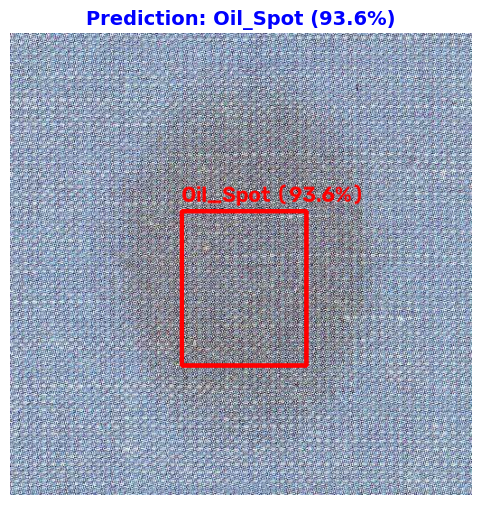

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

if 'fivora_detector' in locals():
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)


            class_preds = predictions['class_output'][0]
            bbox_preds = predictions['bbox_output'][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0] * original_w, bbox_preds[1] * original_h
            w, h = bbox_preds[2] * original_w, bbox_preds[3] * original_h

            x_min, y_min = int(x_center - (w / 2)), int(y_center - (h / 2))
            x_max, y_max = int(x_center + (w / 2)), int(y_center + (h / 2))


            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(original_w, x_max), min(original_h, y_max)


            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving holeeee.jfif to holeeee.jfif


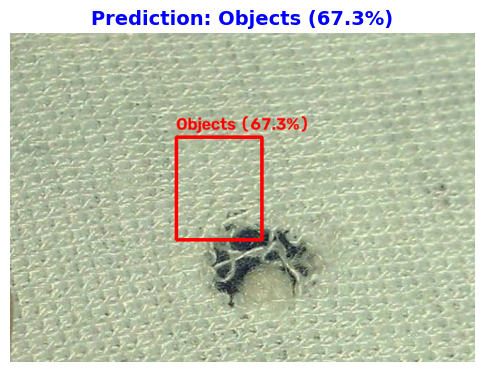

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

if 'fivora_detector' in locals():
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)


            class_preds = predictions['class_output'][0]
            bbox_preds = predictions['bbox_output'][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0] * original_w, bbox_preds[1] * original_h
            w, h = bbox_preds[2] * original_w, bbox_preds[3] * original_h

            x_min, y_min = int(x_center - (w / 2)), int(y_center - (h / 2))
            x_max, y_max = int(x_center + (w / 2)), int(y_center + (h / 2))


            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(original_w, x_max), min(original_h, y_max)


            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving hole.jfif to hole.jfif


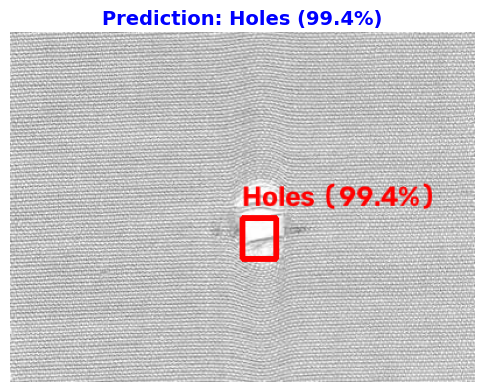

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

if 'fivora_detector' in locals():
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)


            class_preds = predictions['class_output'][0]
            bbox_preds = predictions['bbox_output'][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0] * original_w, bbox_preds[1] * original_h
            w, h = bbox_preds[2] * original_w, bbox_preds[3] * original_h

            x_min, y_min = int(x_center - (w / 2)), int(y_center - (h / 2))
            x_max, y_max = int(x_center + (w / 2)), int(y_center + (h / 2))


            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(original_w, x_max), min(original_h, y_max)


            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()


📤 Please select ONE fabric image file to test:


Saving pinched.jfif to pinched.jfif


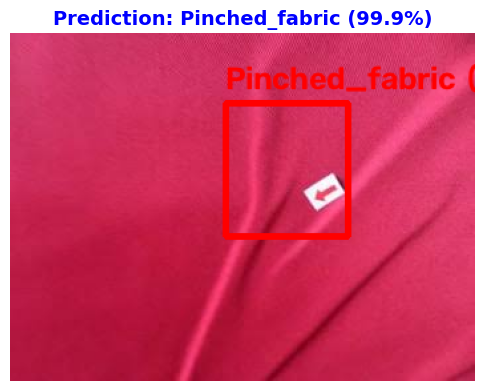

In [ ]:
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt

if 'fivora_detector' in locals():
    print("\n📤 Please select ONE fabric image file to test:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        img = cv2.imread(filename)
        if img is not None:
            original_h, original_w = img.shape[:2]
            display_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img_input = np.expand_dims(cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0, axis=0)
            predictions = fivora_detector.predict(img_input, verbose=0)


            class_preds = predictions['class_output'][0]
            bbox_preds = predictions['bbox_output'][0]

            pred_class_id = np.argmax(class_preds)
            confidence = class_preds[pred_class_id] * 100

            x_center, y_center = bbox_preds[0] * original_w, bbox_preds[1] * original_h
            w, h = bbox_preds[2] * original_w, bbox_preds[3] * original_h

            x_min, y_min = int(x_center - (w / 2)), int(y_center - (h / 2))
            x_max, y_max = int(x_center + (w / 2)), int(y_center + (h / 2))


            x_min, y_min = max(0, x_min), max(0, y_min)
            x_max, y_max = min(original_w, x_max), min(original_h, y_max)


            cv2.rectangle(display_img, (x_min, y_min), (x_max, y_max), (255, 0, 0), 4)
            label = f"{classes[pred_class_id]} ({confidence:.1f}%)"
            cv2.putText(display_img, label, (x_min, max(30, y_min - 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

            plt.figure(figsize=(6, 6))
            plt.imshow(display_img)
            plt.title(f"Prediction: {label}", fontsize=14, color='blue', fontweight='bold')
            plt.axis('off')
            plt.show()